In [1]:
import numpy as np
from ultralytics import YOLOE
import cv2
from matplotlib import pyplot as plt
from IPython.display import display, clear_output

Detecting Camera Frist

In [2]:
# init
print("version of opencv")
cv2.__version__

version of opencv


'5.0.0'

In [3]:
# Capture the exact camera 
for number in range(100): #
    camera = cv2.VideoCapture(number)
    if camera.isOpened():
        success, frame = camera.read()
        if success:
            print(number,"가능")
        camera.release()


0 가능
1 가능


OpenCV: out device of bound (0-1): 2
OpenCV: camera failed to properly initialize!
[ WARN:0@3.285] global cap_ffmpeg_impl.hpp:1240 open VIDEOIO/FFMPEG: Failed list devices for backend avfoundation
OpenCV: out device of bound (0-1): 3
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 4
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 5
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 6
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 7
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 8
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 9
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 10
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 11
OpenCV: camera failed to properly initialize!
OpenCV: out device of bound (0-1): 12
OpenCV: camera f

In [4]:
# capture with camera 
camera = cv2.VideoCapture(0)

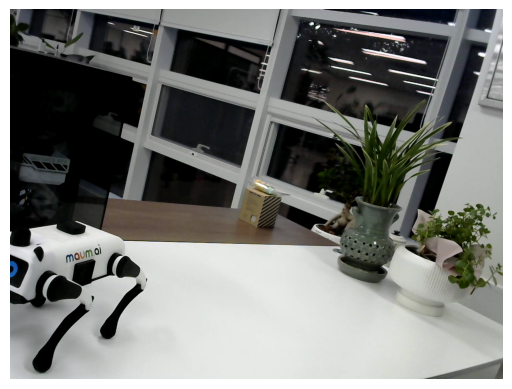

In [5]:
# Display a single image 
success, frame = camera.read() # frame is loaded 
if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

In [6]:
frame.shape

(960, 1280, 3)

enable video detection model

In [7]:
model = YOLOE("yoloe-26n-seg.pt")

In [8]:
# set label to detect 
model.set_classes([
    "dog-robot",
    "Standing Human",
    "sitting human",
    "plant",
    "pc-moniter"
])

/Users/snucsnl/Desktop/computer_vision/.venv/lib/python3.11/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


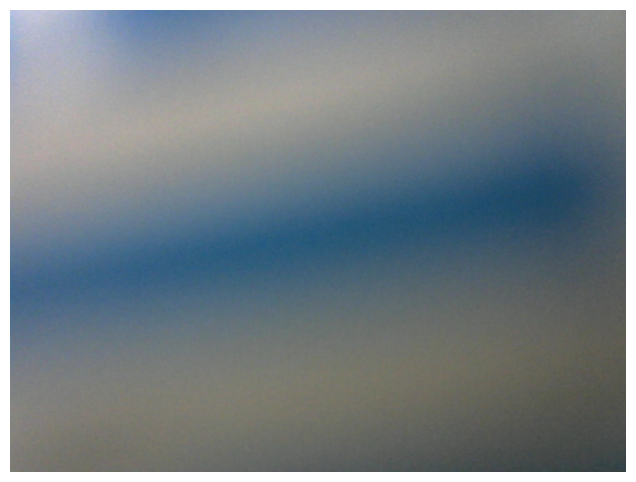

In [ ]:
# live stream
try:
    while True:
        success, frame = camera.read()

        if not success:
            print("카메라 프레임을 읽을 수 없습니다.")
            break

        # 텍스트 프롬프트 기반 객체 탐지
        results = model.predict(
            source=frame,
            verbose=False
        )
        # 탐지 결과를 원본 프레임에 표시
        annotated_frame = results[0].plot()
        annotated_frame = cv2.cvtColor(
            annotated_frame,
            cv2.COLOR_BGR2RGB
        )

        clear_output(wait=True)
        plt.figure(figsize=(10, 6))
        plt.imshow(annotated_frame)
        plt.axis("off")
        display(plt.gcf())
        plt.close()

except KeyboardInterrupt:
    print("탐지를 종료했습니다.")

finally:
    camera.release()

No multiple objects detection ? also suspicious require a temporal data... More time -> more vram...
One shot to determine whether the object? 
Distance matters a lot in object detection. If the object is too far, it may not be detected properly.
It means the score is not a valid threshold...

박수석님 
* custom dection - limit and performance
    * computing power, vram, 
    * fps, latency,
    * detection score, 
        * especially soft negative

how do we should define a "guard", to be sure about minimal false positive and 0% false negative?
what can this robots do, especially in the context of security and surveillance?
What best matches the living thing? a real guard or guard dog?
